# Import Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as matt
import seaborn as sns
import re 

# Import Table 5-1 as a CSV and create a height column

In [25]:
table = pd.read_csv('Table5-1.csv').sort_values(by = 'Ag(in^2)', ascending = True) #reads in a CSV of the table of beam options in the AISC manual
                                            #sorting it by Ag allows findBeam to return the lightest and most economical beam for a given scenario


options = table['Shape'] #the "Shape" column is the beam shapes (ex. "W10x412"). these are the options our function will choose from
strengthRupture = table['Rupture_ASD(kips)'] #these are the strength values for a rupture limit state. Using just values from ASD method for simplicity
strengthYielding = table['Yielding_ASD(kips)'] #these are the strength values for a yielding limit state.

length = len(options) #defines length as the total number of options

table['Height(in)'] = table['Shape'].str.extract("(?<=W)(.*?)(?=x)")

height = table['Height(in)'] 

In [26]:
table.head()

,Shape,Ag(in^2),Ae(in^2),Yielding_ASD(kips),Yielding_LRFD(kips),Rupture_ASD(kips),Rupture_LRFD(kips),Height(in)
0,W8x10,2.96,2.22,88.6,133,72.2,108,8
1,W10x12,3.54,2.66,106.0,159,86.5,130,10
2,W8x13,3.84,2.88,115.0,173,93.6,140,8
3,W12x14,4.16,3.12,125.0,187,101.0,152,12
4,W10x15,4.41,3.31,132.0,198,108.0,161,10


# Define function to find the limit state
It's worth noting that this will alway result in a rupture limit state using the default steel strength values (Fy and Fu) from Table 5-1

In [27]:
def findLimitState(Ae, Ag, Fy, Fu): #automates the equation from the manual
    if (Ae/Ag) >= 1.2*(Fy/Fu):
        return "Yielding Limit State"
    elif (Ae/Ag) < 1.2*(Fy/Fu):
        return "Rupture Limit State"
    else:
        return "ERROR - Could not determine Limit State"

# Define a function to find a suitable beam

In [33]:
#selected lightest beam based on desired height, load, and limit state
def findBeam (desiredHeight, load, Ae, Ag, Fy, Fu):
    limitState = findLimitState(Ae, Ag, Fy, Fu) #determinees the limit state using previously defined function
    #print(limitState)
    if limitState == 'Rupture Limit State':
        for i in range(length): #search through the table
            if strengthRupture[i] >= load and str(desiredHeight) == height[i]: #checks height and if the strength is suitable for the load
                return options[i] #returns a suitable beam shape  
    if limitState == 'Yielding Limit State':            
        for i in range(length): #search through the table
            if strengthYielding[i] >= load and str(desiredHeight) == height[i]: #checks height and if the strength is suitable for the load
                return options[i] #returns a suitable beam shape
    if limitState == "Error Finding Limit State":
        return "ERROR - Could not determine limit state"
    else:
        return "ERROR - Could not find suitable beam"

# Modify findBeam to include user inputs

In [34]:
def findBeam_w_inputs():
    desiredHeight = input("Input desired beam height (in): ")
    load = float(input("Input load (kips): "))
    
    assumptions = input("Use assumed effective net area values from table? (y/n): ")
    if assumptions == 'n':
        Ag = 1
        Ae = float(input("Input beam net effective area as a decimal percent of gross area: "))
        Fy = 65 #float(input("Input steel yielding strength (ksi): "))
        Fu = 50 #float(input("Input steel ultimate strength (ksi): "))
    elif assumptions == 'y':
        #assumed values from table 5-1
        Ag = 1 # Gross Area (in^2)
        Ae = 0.75*Ag # Effective Area (in^2)
        Fy = 50 #yield strength (ksi)
        Fu = 65 # ultimated strength (ksi)
    
    choice = findBeam (desiredHeight, load, Ae, Ag, Fy, Fu)
    print(choice)

Run the function to test it:

In [36]:
findBeam_w_inputs()

Input desired beam height (in):  13
Input load (kips):  10
Use assumed effective net area values from table? (y/n):  y


ERROR - Could not find suitable beam


# Plot beam strength by beam gross crossectional area

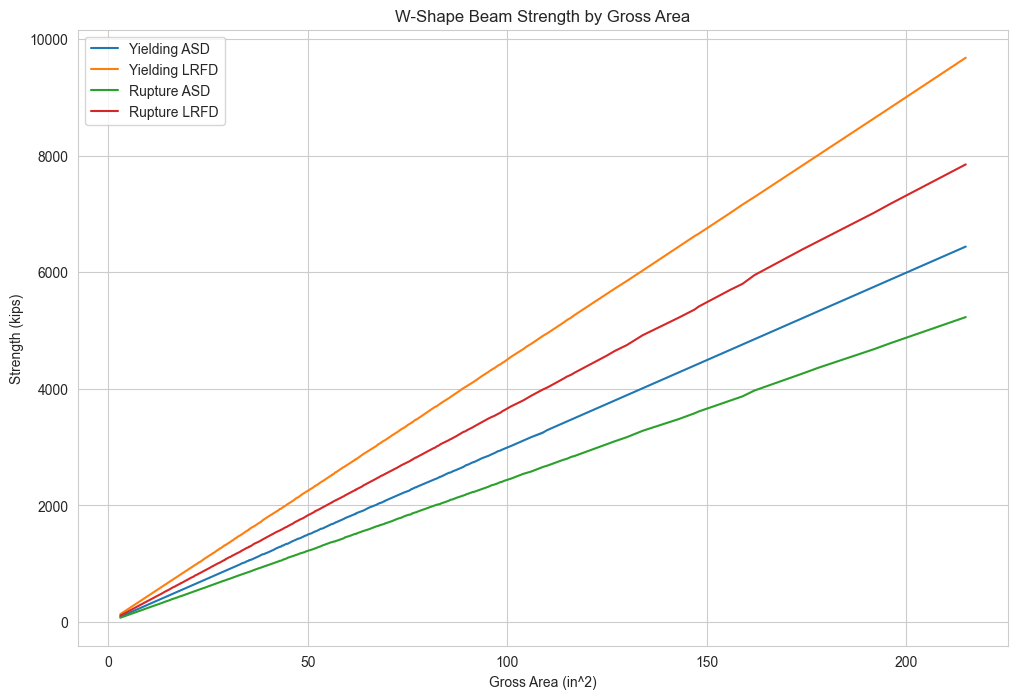

In [43]:
sns.set_style('whitegrid')

matt.figure(figsize = (12,8))
sns.lineplot(x = table['Ag(in^2)'], y = table['Yielding_ASD(kips)'], label = 'Yielding ASD')
sns.lineplot(x = table['Ag(in^2)'], y = table['Yielding_LRFD(kips)'], label = 'Yielding LRFD')
sns.lineplot(x = table['Ag(in^2)'], y = table['Rupture_ASD(kips)'], label = 'Rupture ASD')
sns.lineplot(x = table['Ag(in^2)'], y = table['Rupture_LRFD(kips)'], label = 'Rupture LRFD')

matt.xlabel('Gross Area (in^2)')
matt.ylabel('Strength (kips)')
matt.title('W-Shape Beam Strength by Gross Area')
matt.legend()

# Graph max beam strength by height
First, group strength by height and get the max strength for each height.

In [154]:
HGY = table.groupby('Height(in)').agg(maxYielding = ('Yielding_ASD(kips)', 'max'))
HGR = table.groupby('Height(in)').agg(maxRupture = ('Rupture_ASD(kips)', 'max'))

HGY.head()

,maxYielding
Height(in),
10,985.0
12,2960.0
14,6440.0
16,880.0
18,2740.0


Then, graph the grouped data.

Text(0, 0.5, 'Max ASD Rupture Strength (kips)')

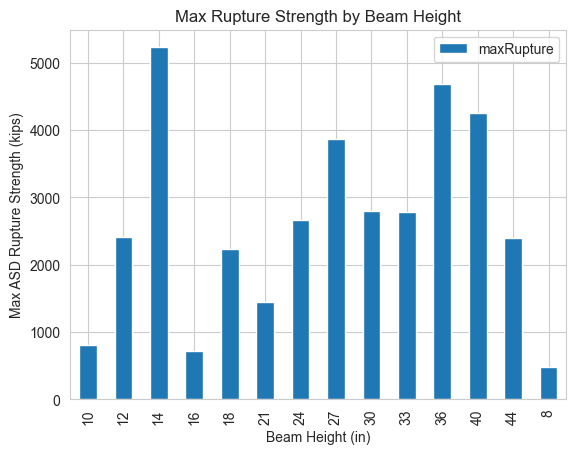

In [160]:
HGR.plot(kind = 'bar')

matt.title('Max Rupture Strength by Beam Height')
matt.xlabel('Beam Height (in)')
matt.ylabel('Max ASD Rupture Strength (kips)')